In [16]:
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False


In [17]:
import pandas as pd
import numpy as np

booktags=pd.read_csv("book_tags.csv")
ratings=pd.read_csv("ratings.csv")
books=pd.read_csv("books.csv")
tags=pd.read_csv("tags.csv")
to_read=pd.read_csv("to_read.csv")


booktags.head()
ratings.head()
books.head()
print(books.columns)
print(ratings.columns)
print(booktags.columns)
print(tags.columns)


Index(['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn',
       'isbn13', 'authors', 'original_publication_year', 'original_title',
       'title', 'language_code', 'average_rating', 'ratings_count',
       'work_ratings_count', 'work_text_reviews_count', 'ratings_1',
       'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url',
       'small_image_url'],
      dtype='object')
Index(['book_id', 'user_id', 'rating'], dtype='object')
Index(['goodreads_book_id', 'tag_id', 'count'], dtype='object')
Index(['tag_id', 'tag_name'], dtype='object')


In [18]:
df=books.merge(ratings,how="left",on="book_id")
df.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url,user_id,rating
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,NaN,NaN
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,314.0,3.0
2,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,588.0,1.0
3,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,2077.0,2.0
4,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,2487.0,3.0


In [19]:
df=df.merge(booktags, left_on='book_id', right_on='goodreads_book_id', how='left')
df=df.merge(tags,on='tag_id', how='left')
df.drop_duplicates(subset=['book_id'],inplace=True)
df.head()

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_4,ratings_5,image_url,small_image_url,user_id,rating,goodreads_book_id,tag_id,count,tag_name
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,NaN,NaN,2767052,11557,50755,favorites
100,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,314.0,3.0,3,30574,496107,to-read
10100,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...,NaN,NaN,41865,33114,16446,young-adult
10200,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...,324.0,4.0,2657,7457,31068,classics
20200,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...,206.0,3.0,4671,7457,32061,classics


In [20]:
df_needed=df[['average_rating','rating','tag_name','count']]
print(df_needed.shape)
df_needed.head()

(10000, 4)


,average_rating,rating,tag_name,count
0,4.34,NaN,favorites,50755
100,4.44,3.0,to-read,496107
10100,3.57,NaN,young-adult,16446
10200,4.25,4.0,classics,31068
20200,3.89,3.0,classics,32061


In [21]:
import warnings
warnings.filterwarnings("ignore")
numeric_columns=df_needed.select_dtypes(include=['int64','float64']).columns
for col in numeric_columns:
    median=df_needed[col].median()
    df_needed.fillna({col:median},inplace=True)
    print(f"Filled missing values in {col} with median:{median}")
categorical_columns=df_needed.select_dtypes(include=['object']).columns
for col in categorical_columns:
    mode = df_needed[col].mode()[0]
    df_needed.fillna({col:mode},inplace=True)
    print(f"Filled missing values in {col} with mode:{mode}")

Filled missing values in average_rating with median:4.02
Filled missing values in rating with median:4.0
Filled missing values in count with median:5278.0
Filled missing values in tag_name with mode:to-read


In [22]:
df_needed.shape

(10000, 4)

In [23]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder=OrdinalEncoder()

df_needed['genre']=ordinal_encoder.fit_transform(df_needed[['tag_name']])
df_needed['label']=(df_needed['rating']>4).astype(int)
df_needed.drop(columns=['tag_name'],inplace=True)

df_needed.head()

,average_rating,rating,count,genre,label
0,4.34,4.0,50755,35.0,0
100,4.44,3.0,496107,86.0,0
10100,3.57,4.0,16446,92.0,0
10200,4.25,4.0,31068,17.0,0
20200,3.89,3.0,32061,17.0,0


In [24]:
x=df_needed[['average_rating','rating','count','genre']].values
y=df_needed['label'].values


now y is array

In [25]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=SEED,stratify=y)
train=TensorDataset(torch.tensor(xtrain,dtype=torch.float32),torch.tensor(ytrain,dtype=torch.float32))
test=TensorDataset(torch.tensor(xtest,dtype=torch.float32),torch.tensor(ytest,dtype=torch.float32))
train_loader=DataLoader(train,batch_size=128,shuffle=True)
test_loader=DataLoader(test,batch_size=128,shuffle=False)

In [26]:
import pandas as pd

print("Train distribution:\n",pd.Series(ytrain).value_counts(normalize=True))
print("Test distribution:\n",pd.Series(ytest).value_counts(normalize=True))


Train distribution:
 0    0.98275
1    0.01725
Name: proportion, dtype: float64
Test distribution:
 0    0.9825
1    0.0175
Name: proportion, dtype: float64


Imbalanced data

In [27]:

print("MLP(multilayer perceptron) MODEL")
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1=nn.Linear(input_dim,3)
        self.relu=nn.ReLU()
        self.fc2=nn.Linear(3,1)

    def forward(self, x):
        x=self.relu(self.fc1(x))
        x=self.fc2(x)
        return x
model=MLP(input_dim=x.shape[1])
negative=(ytrain==0).sum()
positive=(ytrain==1).sum()
positionweight=torch.tensor(negative/positive,dtype=torch.float32)
lossfn=nn.BCEWithLogitsLoss(pos_weight=positionweight)
optimizer=optim.Adam(model.parameters(),lr=0.001)

MLP(multilayer perceptron) MODEL


calculating loss for visualisation
Epoch1,Loss:1.3222911774166046
Epoch2,Loss:1.2497564469064986
Epoch3,Loss:1.179462500980922
Epoch4,Loss:1.1086380566869463
Epoch5,Loss:1.0241484623106698
Epoch6,Loss:0.9411541214064946
Epoch7,Loss:0.8533015289003887
Epoch8,Loss:0.7713613756119259
Epoch9,Loss:0.6946463007775564
Epoch10,Loss:0.6237307332810902
Visualizing this training loss


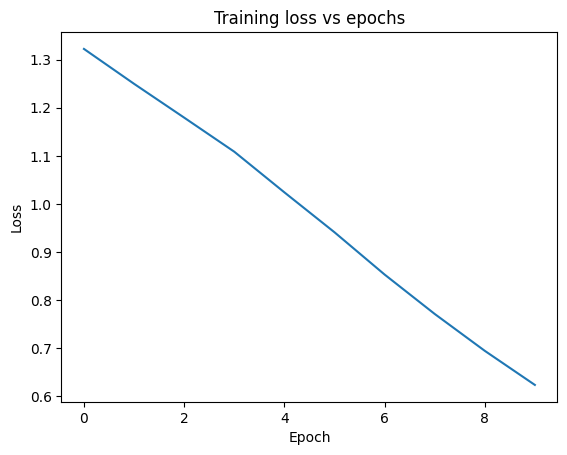

In [28]:
print("calculating loss for visualisation")
losses=[]
for epoch in range(10):
    model.train()
    epochloss=0
    for xb,yb in train_loader:
        optimizer.zero_grad()
        ypred=model(xb).squeeze()
        loss=lossfn(ypred,yb.squeeze())
        loss.backward()
        optimizer.step()
        epochloss+=loss.item()
    avg_loss=epochloss/len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch{epoch+1},Loss:{avg_loss}")

print("Visualizing this training loss")
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss vs epochs")
plt.show()



In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Evaluation")

model.eval()
ypredictlist=[]
ytruelist=[]
with torch.no_grad():
    for xb, yb in test_loader:
        output=model(xb.float()).squeeze()
        print("Sample outputs:",output[:10])
        break
    for xb,yb in test_loader:
        logits=model(xb).squeeze()
        prob=torch.sigmoid(logits)
        ypred=(prob>=0.5).int()
        ytruelist.extend(yb.int().tolist())
        ypredictlist.extend(ypred.tolist())

print("Accuracy score of MLP model:",accuracy_score(ytruelist,ypredictlist))
print("Precision score:",precision_score(ytruelist,ypredictlist))
print("F1 score",f1_score(ytruelist,ypredictlist))
print("Recall score of MLP model:",recall_score(ytruelist,ypredictlist))

Evaluation
Sample outputs: tensor([-0.4992, -0.5024, -0.5333, -0.5046, -0.4513, -0.4156, -0.5028, -0.5039,
        -0.5160, -0.5333])
Accuracy score of MLP model: 0.999
Precision score: 0.9459459459459459
F1 score 0.9722222222222222
Recall score of MLP model: 1.0


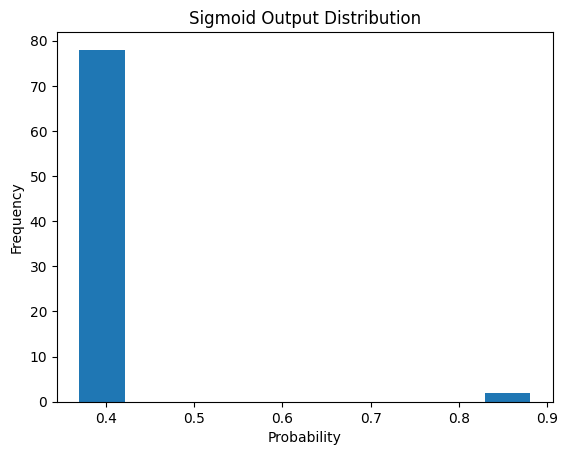

In [30]:
plt.hist(prob.numpy())
plt.title("Sigmoid Output Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()
